# ROC curves for plume-detectability MLP (paper revision)

Per reviewer request (§4.3): show one ROC curve per analysis. Loads the
best-of-5-runs item-split MLP for US and Global, replays the best run's
test fold (parsed from the training log), computes ROC and AUC on that
fold, and plots a 1×2 figure with the AUC annotated.

Output: `roc_curves.{pdf,png}` under
`/net/fs06/d3/rzhuang/TROPOMI/data/us/Run_100m_20260414/paper_figures/`.

In [1]:
import os, re, sys, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.metrics import roc_curve, roc_auc_score, average_precision_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

ROOT = Path('/net/fs06/d3/rzhuang/TROPOMI/code')
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / '6_training'))
from config import TRAINING
from shared.features import get_feature_list
from shared.interference import (identify_interference_us_by_year,
                                  identify_interference_world,
                                  extract_year_from_datetime)
from shared.model import MLP

# ── Style ────────────────────────────────────────────────────────────
nimbus = next((p for p in fm.findSystemFonts()
               if 'nimbusroman' in p.lower() and 'bold' not in p.lower()
               and 'italic' not in p.lower()), None)
if nimbus:
    fm.fontManager.addfont(nimbus)
plt.rcdefaults()
plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'Nimbus Roman' if nimbus else 'serif',
    'font.size': 12,
    'axes.linewidth': 0.8, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#2E3440', 'axes.labelcolor': '#2E3440', 'text.color': '#2E3440',
    'xtick.color': '#2E3440', 'ytick.color': '#2E3440',
    'figure.facecolor': 'white',
})
COLORS = {'US': '#FF6B6B', 'Global': '#4ECDC4'}

In [2]:
# ── Paths ────────────────────────────────────────────────────────────
US_PATHS = {
    'data_csv':            '/net/fs06/d3/rzhuang/TROPOMI/pipeline_100m_run/Run_100m_20260414/'
                            'updated_tropomi_hourly_emissions_full_variables_augmented_localtz.csv',
    'plant_csv':           '/net/fs06/d3/rzhuang/TROPOMI/data/us/'
                            'facility_emissions_by_plant_comprehensive.csv',
    'annual_emissions_csv': '/net/fs06/d3/rzhuang/TROPOMI/data/us/'
                            'annual-emissions-facility-aggregation-2019-2024.csv',
    'cities_csv':          '/net/fs06/d3/rzhuang/TROPOMI/data/world/worldcities.csv',
    'model_dir':           '/net/fs06/d3/rzhuang/TROPOMI/data/us/Run_100m_20260414/'
                            'training_no_stats_item',
    'log':                 '/net/fs06/d3/rzhuang/TROPOMI/code/slurm/training/logs/train_us_item.out',
    'ds_name':             'all_data_filtered_yearly',
    'data_type':           'hourly',
}
WORLD_PATHS = {
    'data_csv':            '/net/fs06/d3/rzhuang/TROPOMI/data/world/pipeline_test_labelling_100m/'
                            'Run_100m_20260428/updated_tropomi_emissions_full_variables_with_fuel_100mlabel.csv',
    'plant_csv':           '/net/fs06/d3/rzhuang/TROPOMI/data/world/power_plant_location/'
                            'power_plants_with_combined_nearby_stats.csv',
    'cities_csv':          '/net/fs06/d3/rzhuang/TROPOMI/data/world/worldcities.csv',
    'model_dir':           '/net/fs06/d3/rzhuang/TROPOMI/data/world/pipeline_test_labelling_100m/'
                            'Run_100m_20260428/training_no_stats_item',
    'log':                 '/net/fs06/d3/rzhuang/TROPOMI/code/slurm/training/logs/train_world_item.out',
    'ds_name':             'all_data_filtered',
    'data_type':           'annual',
}
OUT_DIR = '/net/fs06/d3/rzhuang/TROPOMI/data/us/Run_100m_20260414/paper_figures'
os.makedirs(OUT_DIR, exist_ok=True)

In [3]:
# ── Helpers: parse log, replay split, predict ────────────────────────
def parse_best_run(log_path, ds_name):
    text = Path(log_path).read_text()
    blocks = re.split(r'=+\n([a-zA-Z_0-9]+):\s*\d+\s*samples', text)
    for i in range(1, len(blocks), 2):
        if blocks[i].strip() != ds_name: continue
        body = blocks[i+1] if i+1 < len(blocks) else ''
        runs = re.findall(r'--- Run (\d)/5 ---.*?Test AUC: (\d+\.\d+)', body, re.S)
        runs = [(int(r) - 1, float(a)) for r, a in runs]
        return max(runs, key=lambda x: x[1])  # (run_idx, test_auc)
    raise KeyError(f'{ds_name} not found in {log_path}')

def split_item(X, y, run):
    seed = TRAINING['split_seed_sweep'] + run
    val_r = TRAINING['val_ratio']
    tr_r, te_r = TRAINING['train_ratio'], TRAINING['test_ratio']
    X_tt, X_val, y_tt, y_val = train_test_split(X, y, test_size=val_r, random_state=seed)
    rel_te = te_r / (tr_r + te_r)
    X_tr, X_te, y_tr, y_te = train_test_split(X_tt, y_tt, test_size=rel_te, random_state=seed + 1)
    return X_te, y_te

def load_us_dataset(features):
    p = US_PATHS
    tropomi = pd.read_csv(p['data_csv']).dropna()
    le = LabelEncoder(); tropomi['primary_fuel_type'] = le.fit_transform(tropomi['primary_fuel_type'])
    plants = pd.read_csv(p['plant_csv'])
    if 'NOx_Rank' in plants.columns:
        plants = plants.sort_values('NOx_Rank', ascending=True)
    cities = pd.read_csv(p['cities_csv'])
    annual_emis = pd.read_csv(p['annual_emissions_csv'])
    tropomi = extract_year_from_datetime(tropomi)
    US_YEARS = [2019, 2020, 2021, 2022, 2023, 2024]
    pids = tropomi['location'].unique().tolist()
    emis_top = annual_emis[annual_emis['Facility ID'].isin(pids)]
    present_yrs = (emis_top[emis_top['Year'].isin(US_YEARS)]
                   .groupby('Facility ID')['Year'].nunique())
    complete_6y_ids = set(present_yrs[present_yrs == len(US_YEARS)].index)
    pids_strict = [pp for pp in pids if pp in complete_6y_ids]
    pdf_strict = plants[plants['Facility_ID'].isin(pids_strict)]
    emis_strict = emis_top[emis_top['Facility ID'].isin(pids_strict)]
    interf = identify_interference_us_by_year(pdf_strict, emis_strict, cities,
                                                plant_subset_ids=pids_strict)
    kept_ids = complete_6y_ids - set().union(*[set(v) for v in interf.values()])
    return tropomi[tropomi['location'].isin(kept_ids)].copy()

def load_world_dataset(features):
    p = WORLD_PATHS
    tropomi = pd.read_csv(p['data_csv'])
    tropomi = tropomi.dropna(subset=features + ['plume_label', 'location'])
    le = LabelEncoder(); tropomi['primary_fuel_type'] = le.fit_transform(tropomi['primary_fuel_type'])
    plants = pd.read_csv(p['plant_csv'])
    cities = pd.read_csv(p['cities_csv'])
    pids = tropomi['location'].unique().tolist()
    pdf = plants[plants['ID'].isin(pids)]
    interf = identify_interference_world(pdf, cities, plant_subset_ids=pids)
    return tropomi[~tropomi['location'].isin(interf)].copy()

In [4]:
# ── Compute ROC for both regions ─────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
results = {}

for region, paths, loader in [('US', US_PATHS, load_us_dataset),
                                ('Global', WORLD_PATHS, load_world_dataset)]:
    print(f'\n=== {region} ===')
    features = get_feature_list('no_stats',
                                  'us' if region == 'US' else 'world',
                                  paths['data_type'])
    best_run, log_auc = parse_best_run(paths['log'], paths['ds_name'])
    print(f'  best run from log: r{best_run}, log Test AUC = {log_auc:.4f}')

    ds = loader(features)
    X = ds[features].values.astype(np.float32)
    y = ds['plume_label'].astype(int).values
    X_te, y_te = split_item(X, y, best_run)
    print(f'  test rows: {len(X_te):,} | pos = {y_te.sum()} ({y_te.mean()*100:.1f}%)')

    scaler = joblib.load(Path(paths['model_dir']) / f"best_scaler_{paths['ds_name']}.pkl")
    X_te_s = scaler.transform(X_te).astype(np.float32)

    model = MLP(input_dim=len(features)).to(device)
    model.load_state_dict(torch.load(
        Path(paths['model_dir']) / f"best_model_{paths['ds_name']}.pt",
        map_location=device))
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(torch.from_numpy(X_te_s).to(device))).cpu().numpy()

    fpr, tpr, _ = roc_curve(y_te, probs)
    auc = float(roc_auc_score(y_te, probs))
    pr_auc = float(average_precision_score(y_te, probs))
    print(f'  ROC-AUC = {auc:.4f} (log: {log_auc:.4f}) | PR-AUC = {pr_auc:.4f}')

    results[region] = {
        'fpr': fpr, 'tpr': tpr, 'auc': auc, 'pr_auc': pr_auc,
        'n_test': len(y_te), 'n_pos': int(y_te.sum()), 'n_neg': int((1-y_te).sum()),
        'pos_rate': float(y_te.mean()),
    }


=== US ===
  best run from log: r3, log Test AUC = 0.8274
Identifying plants in interference zones by year...
Year 2019: 283 interfered / 460 plants
Year 2020: 283 interfered / 460 plants
Year 2021: 283 interfered / 460 plants
Year 2022: 283 interfered / 460 plants
Year 2023: 283 interfered / 460 plants
Year 2024: 283 interfered / 460 plants
  test rows: 37,943 | pos = 12823 (33.8%)
  ROC-AUC = 0.8274 (log: 0.8274) | PR-AUC = 0.7575

=== Global ===
  best run from log: r2, log Test AUC = 0.8043
Identifying plants in interference zones (global)...


Checking interference: 100%|██████████| 6000/6000 [00:02<00:00, 2016.60it/s]


Found 4935 interfered / 6000 plants
  test rows: 32,224 | pos = 12581 (39.0%)
  ROC-AUC = 0.8043 (log: 0.8043) | PR-AUC = 0.7591


Saved: /net/fs06/d3/rzhuang/TROPOMI/data/us/Run_100m_20260414/paper_figures/roc_curves.pdf
Saved: /net/fs06/d3/rzhuang/TROPOMI/data/us/Run_100m_20260414/paper_figures/roc_curves.png


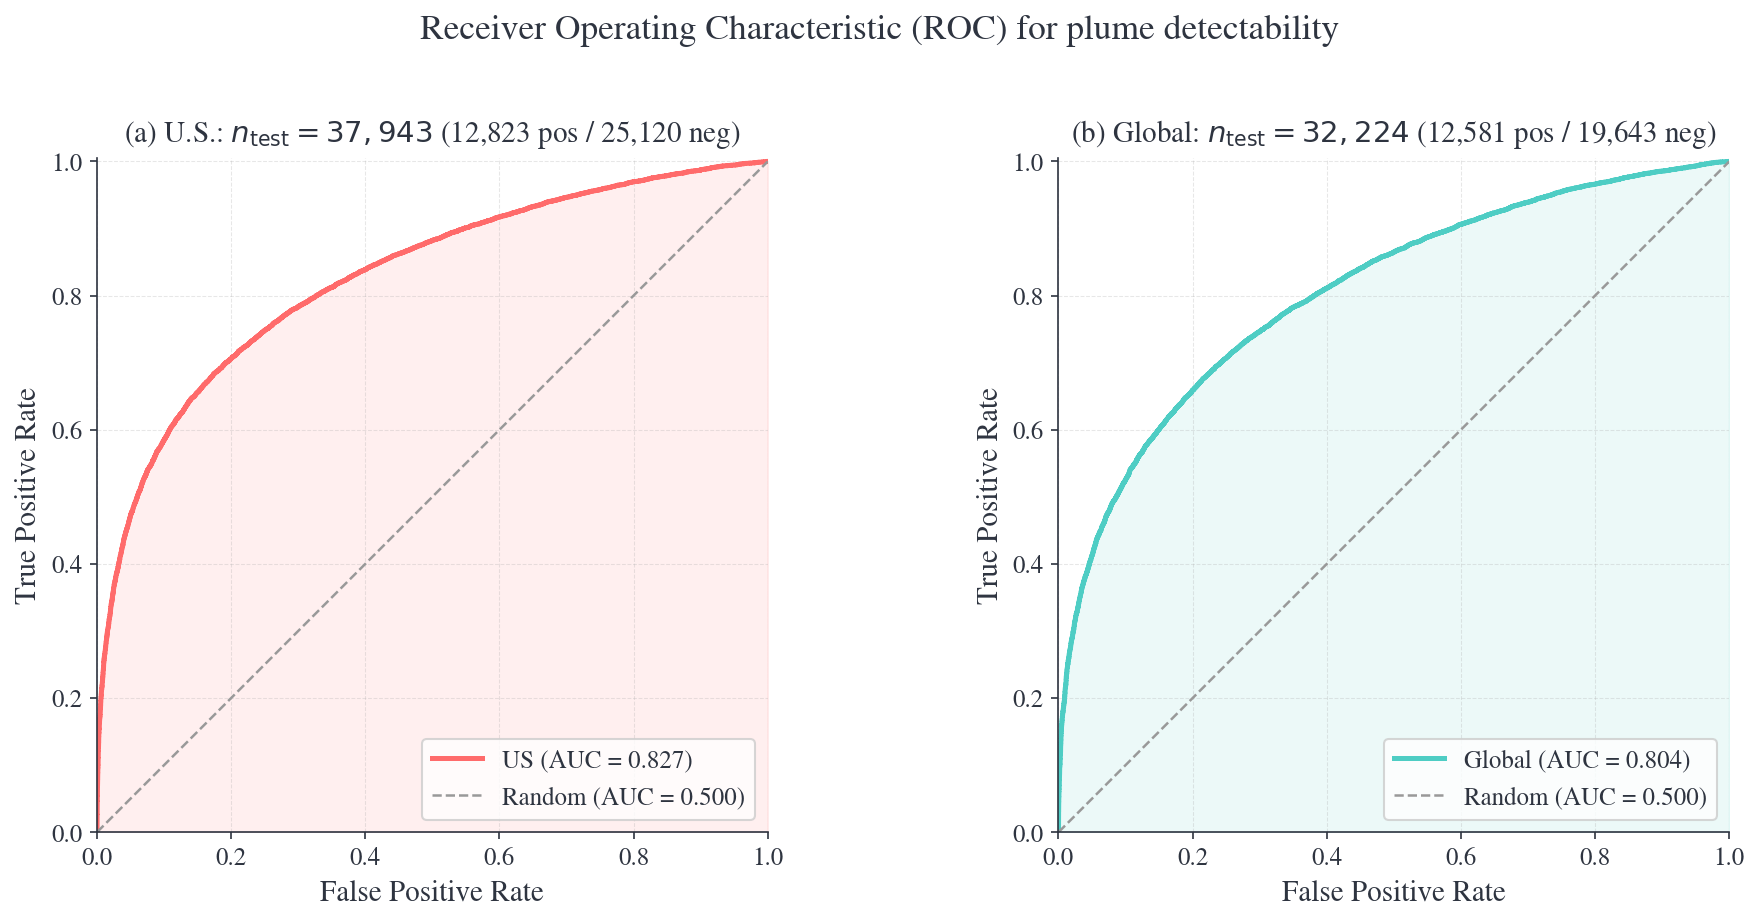


=== Summary ===
  US     : AUC=0.8274  PR-AUC=0.7575  n_test=37,943  pos_rate=33.8%
  Global : AUC=0.8043  PR-AUC=0.7591  n_test=32,224  pos_rate=39.0%


In [6]:
# ── Plot 1×2 ROC curves ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 6), facecolor='white')

panels = [('US', '(a) U.S.', axes[0]), ('Global', '(b) Global', axes[1])]
for region, title, ax in panels:
    r = results[region]
    ax.plot(r['fpr'], r['tpr'], color=COLORS[region], linewidth=2.4,
             label=f"{region} (AUC = {r['auc']:.3f})")
    ax.plot([0, 1], [0, 1], '--', color='#999999', linewidth=1.2,
             label='Random (AUC = 0.500)')
    ax.fill_between(r['fpr'], r['tpr'], alpha=0.10, color=COLORS[region])
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.005)
    ax.set_xlabel('False Positive Rate', fontsize=14, fontweight='600')
    ax.set_ylabel('True Positive Rate',  fontsize=14, fontweight='600')
    ax.set_title(f"{title}: $n_\\mathrm{{test}}={r['n_test']:,}$ "
                 f"({r['n_pos']:,} pos / {r['n_neg']:,} neg)",
                  fontsize=14, fontweight='700', pad=8)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.legend(loc='lower right', fontsize=12, frameon=True, fancybox=True)
    ax.set_aspect('equal', adjustable='box')

fig.suptitle('Receiver Operating Characteristic (ROC) for plume detectability',
              fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
out_pdf = os.path.join(OUT_DIR, 'roc_curves.pdf')
out_png = os.path.join(OUT_DIR, 'roc_curves.png')
plt.savefig(out_pdf, dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(out_png, dpi=300, bbox_inches='tight', facecolor='white')
print(f'Saved: {out_pdf}')
print(f'Saved: {out_png}')
plt.show()

# Summary table
print('\n=== Summary ===')
for region in ('US', 'Global'):
    r = results[region]
    print(f"  {region:<7s}: AUC={r['auc']:.4f}  PR-AUC={r['pr_auc']:.4f}  "
          f"n_test={r['n_test']:,}  pos_rate={r['pos_rate']*100:.1f}%")